In [137]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, top_k_accuracy_score

In [8]:
data_path = Path("..") / "data" / "data_org.csv"
if not data_path.exists():
    data_path = Path("data") / "data_org.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Data file not found: {data_path}")

data = pd.read_csv(data_path)
print("data loaded successfully")
print(data.head(10))

data loaded successfully
   Python  Java  C++  JavaScript  C#  PHP  Ruby  Swift  Go  Rust  ...  \
0       9     4    9           7   8    1     5      8   6     4  ...   
1       7     7    4           8   8    9     5      2   8     0  ...   
2       1     1    5           8   5    8     0      9   5     9  ...   
3       3     7    5           7   8    7     4      0   3     2  ...   
4       6     9    2           8   4    4     6      3   9     0  ...   
5       7     4    5           8   3    0     6      3   0     1  ...   
6       6     9    8           2   7    1     1      1   8     1  ...   
7       2     1    5           4   1    7     9      7   5     0  ...   
8       9     5    5           4   8    4     1      8   2     3  ...   
9       6     3    6           0   8    6     3      4   1     4  ...   

   Time_Management  Adaptability       GPA  Coursework_Completion_Status  \
0                9             1  2.973938                   In Progress   
1                6 

In [12]:
print("Rows: ", data.shape[0])
print("Columns: ", data.shape[1])

Rows:  8000
Columns:  28


In [14]:
print("All Columns of the dataset: ")
print(data.columns.to_list())

print("Information adout the dataset: ")
print(data.info())

All Columns of the dataset: 
['Python', 'Java', 'C++', 'JavaScript', 'C#', 'PHP', 'Ruby', 'Swift', 'Go', 'Rust', 'Others', 'Software_Development_Experience', 'Database_Management', 'Networking_Skills', 'Web_Development_Experience', 'Communication_Skills', 'Problem_Solving_Abilities', 'Teamwork_Collaboration', 'Time_Management', 'Adaptability', 'GPA', 'Coursework_Completion_Status', 'Academic_Achievements', 'Personal_Interests', 'Internship_Experience', 'Certifications_Training', 'Leadership_Experience', 'Career_Goals']
Information adout the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Python                           8000 non-null   int64  
 1   Java                             8000 non-null   int64  
 2   C++                              8000 non-null   int64  
 3   JavaScript           

In [16]:
print("Discription of the dataset: ")
print(data.describe(include='all'))

Discription of the dataset: 
             Python         Java          C++   JavaScript           C#  \
count   8000.000000  8000.000000  8000.000000  8000.000000  8000.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN   
mean       4.495875     4.515125     4.523375     4.467000     4.501625   
std        2.850745     2.852462     2.885047     2.852749     2.891893   
min        0.000000     0.000000     0.000000     0.000000     0.000000   
25%        2.000000     2.000000     2.000000     2.000000     2.000000   
50%        4.000000     4.000000     5.000000     4.000000     4.000000   
75%        7.000000     7.000000     7.000000     7.000000     7.000000   
max        9.000000     9.000000     9.000000     9.000000     9.000000   

                PHP         Ruby        Swift           Go         Rus

In [18]:
missing = data.isnull().sum()
print("Missing values :", missing)

""" if any  missing values are found, 
we can handle them by either dropping the rows or filling them with appropriate values. 
For example, we can fill missing numerical values with the mean or median, and categorical values with the mode. 
using data.fillna(data.mean(), inplace=True) for numerical columns and data.fillna(data.mode().iloc[0], inplace=True) for categorical columns.
and to drop them data.dropna(inplace=True)
"""


Missing values : Python                             0
Java                               0
C++                                0
JavaScript                         0
C#                                 0
PHP                                0
Ruby                               0
Swift                              0
Go                                 0
Rust                               0
Others                             0
Software_Development_Experience    0
Database_Management                0
Networking_Skills                  0
Web_Development_Experience         0
Communication_Skills               0
Problem_Solving_Abilities          0
Teamwork_Collaboration             0
Time_Management                    0
Adaptability                       0
GPA                                0
Coursework_Completion_Status       0
Academic_Achievements              0
Personal_Interests                 0
Internship_Experience              0
Certifications_Training            0
Leadership_Experience

Missing values : Python                             0
Java                               0
C++                                0
JavaScript                         0
C#                                 0
PHP                                0
Ruby                               0
Swift                              0
Go                                 0
Rust                               0
Others                             0
Software_Development_Experience    0
Database_Management                0
Networking_Skills                  0
Web_Development_Experience         0
Communication_Skills               0
Problem_Solving_Abilities          0
Teamwork_Collaboration             0
Time_Management                    0
Adaptability                       0
GPA                                0
Coursework_Completion_Status       0
Academic_Achievements              0
Personal_Interests                 0
Internship_Experience              0
Certifications_Training            0
Leadership_Experience

'to handle duplicates we can use the drop_duplicates() method.\ndata.drop_duplicates(inplace=True)'

In [21]:
duplicates = data.duplicated().sum()
print("Number of duplicate rows: ", duplicates)
"""to handle duplicates we can use the drop_duplicates() method.
data.drop_duplicates(inplace=True)
in this case, we will not drop duplicates as we want to keep all the data for analysis for accurate results."""

Number of duplicate rows:  0


Number of duplicate rows:  0


'to handle duplicates we can use the drop_duplicates() method.\ndata.drop_duplicates(inplace=True)\nin this case, we will not drop duplicates as we want to keep all the data for analysis for accurate results.'

In [27]:
"""already calculated number of coulmns"""
for i, column in enumerate(data.columns, start=1):
    print(i,"->",column,"->", data[column].dtype)

1 -> Python -> int64
2 -> Java -> int64
3 -> C++ -> int64
4 -> JavaScript -> int64
5 -> C# -> int64
6 -> PHP -> int64
7 -> Ruby -> int64
8 -> Swift -> int64
9 -> Go -> int64
10 -> Rust -> int64
11 -> Others -> int64
12 -> Software_Development_Experience -> int64
13 -> Database_Management -> int64
14 -> Networking_Skills -> int64
15 -> Web_Development_Experience -> int64
16 -> Communication_Skills -> int64
17 -> Problem_Solving_Abilities -> int64
18 -> Teamwork_Collaboration -> int64
19 -> Time_Management -> int64
20 -> Adaptability -> int64
21 -> GPA -> float64
22 -> Coursework_Completion_Status -> object
23 -> Academic_Achievements -> object
24 -> Personal_Interests -> object
25 -> Internship_Experience -> object
26 -> Certifications_Training -> object
27 -> Leadership_Experience -> object
28 -> Career_Goals -> object


In [31]:
for column in data.columns:
    print("\n" + "=" * 60)
    print("Column: ", column)
    print("Unique values: ", data[column].nunique())
    if data[column].nunique() <= 20:
        print(data[column].nunique())


Column:  Python
Unique values:  10
10

Column:  Java
Unique values:  10
10

Column:  C++
Unique values:  10
10

Column:  JavaScript
Unique values:  10
10

Column:  C#
Unique values:  10
10

Column:  PHP
Unique values:  10
10

Column:  Ruby
Unique values:  10
10

Column:  Swift
Unique values:  10
10

Column:  Go
Unique values:  10
10

Column:  Rust
Unique values:  10
10

Column:  Others
Unique values:  10
10

Column:  Software_Development_Experience
Unique values:  10
10

Column:  Database_Management
Unique values:  10
10

Column:  Networking_Skills
Unique values:  10
10

Column:  Web_Development_Experience
Unique values:  10
10

Column:  Communication_Skills
Unique values:  10
10

Column:  Problem_Solving_Abilities
Unique values:  10
10

Column:  Teamwork_Collaboration
Unique values:  10
10

Column:  Time_Management
Unique values:  10
10

Column:  Adaptability
Unique values:  10
10

Column:  GPA
Unique values:  4
4

Column:  Coursework_Completion_Status
Unique values:  2
2

Column:  A

In [37]:
numerical_columns = data.select_dtypes(
    include = ["int64", "float64"]
).columns.tolist()

categorical_columns = data.select_dtypes(
    include = ["object", "category"]
).columns.tolist()

print("Numerical columns: ", numerical_columns)
print("\n" + "=" * 60)
print("Categorical columns: ", categorical_columns)

Numerical columns:  ['Python', 'Java', 'C++', 'JavaScript', 'C#', 'PHP', 'Ruby', 'Swift', 'Go', 'Rust', 'Others', 'Software_Development_Experience', 'Database_Management', 'Networking_Skills', 'Web_Development_Experience', 'Communication_Skills', 'Problem_Solving_Abilities', 'Teamwork_Collaboration', 'Time_Management', 'Adaptability', 'GPA']

Categorical columns:  ['Coursework_Completion_Status', 'Academic_Achievements', 'Personal_Interests', 'Internship_Experience', 'Certifications_Training', 'Leadership_Experience', 'Career_Goals']


In [40]:
print(data["Career_Goals"].value_counts())

print("Number of unique career goals: ", data["Career_Goals"].nunique())

Career_Goals
Computer and Information Systems Manager       222
DevOps Engineer                                219
Digital Marketing Specialist                   218
Computer Network Architect                     217
Data Scientist                                 216
Research Scientist                             214
IT Project Manager                             214
Front End Developer                            210
Software Developer                             209
Network Engineer                               209
Technical Support Engineer                     209
Computer Programmer                            208
Machine Learning Engineer                      208
Game Developer                                 208
Software Tester                                206
Business Intelligence Analyst                  206
Computer Science Teacher                       206
Cybersecurity Analyst                          205
Software Engineer                              204
Cloud Architect   

In [42]:
data[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Python,8000.0,4.495875,2.850745,0.000000,2.000000,4.000000,7.000000,9.000000
Java,8000.0,4.515125,2.852462,0.000000,2.000000,4.000000,7.000000,9.000000
C++,8000.0,4.523375,2.885047,0.000000,2.000000,5.000000,7.000000,9.000000
JavaScript,8000.0,4.467000,2.852749,0.000000,2.000000,4.000000,7.000000,9.000000
C#,8000.0,4.501625,2.891893,0.000000,2.000000,4.000000,7.000000,9.000000
PHP,8000.0,4.488750,2.887458,0.000000,2.000000,4.000000,7.000000,9.000000
Ruby,8000.0,4.487500,2.899292,0.000000,2.000000,4.000000,7.000000,9.000000
Swift,8000.0,4.494625,2.864349,0.000000,2.000000,4.000000,7.000000,9.000000
Go,8000.0,4.520375,2.874912,0.000000,2.000000,5.000000,7.000000,9.000000
Rust,8000.0,4.453625,2.855148,0.000000,2.000000,4.000000,7.000000,9.000000


In [46]:
for column in data.columns:
    print("\n" + "=" * 60)
    print(column)
    print("Unique values:", data[column].nunique())

    if data[column].nunique() <= 15:
        print("Values:", data[column].unique())


Python
Unique values: 10
Values: [9 7 1 3 6 2 8 5 0 4]

Java
Unique values: 10
Values: [4 7 1 9 5 3 2 8 6 0]

C++
Unique values: 10
Values: [9 4 5 2 8 6 1 7 3 0]

JavaScript
Unique values: 10
Values: [7 8 2 4 0 3 6 5 1 9]

C#
Unique values: 10
Values: [8 5 4 3 7 1 9 6 0 2]

PHP
Unique values: 10
Values: [1 9 8 7 4 0 6 5 3 2]

Ruby
Unique values: 10
Values: [5 0 4 6 1 9 3 2 7 8]

Swift
Unique values: 10
Values: [8 2 9 0 3 1 7 4 6 5]

Go
Unique values: 10
Values: [6 8 5 3 9 0 2 1 7 4]

Rust
Unique values: 10
Values: [4 0 9 2 1 3 5 7 6 8]

Others
Unique values: 10
Values: [7 3 0 2 6 5 4 8 1 9]

Software_Development_Experience
Unique values: 10
Values: [2 8 5 4 6 9 0 3 1 7]

Database_Management
Unique values: 10
Values: [3 9 0 4 2 8 6 5 1 7]

Networking_Skills
Unique values: 10
Values: [7 2 3 5 9 6 8 0 1 4]

Web_Development_Experience
Unique values: 10
Values: [5 1 6 7 8 0 9 2 3 4]

Communication_Skills
Unique values: 10
Values: [7 3 0 1 2 8 4 5 6 9]

Problem_Solving_Abilities
Unique valu

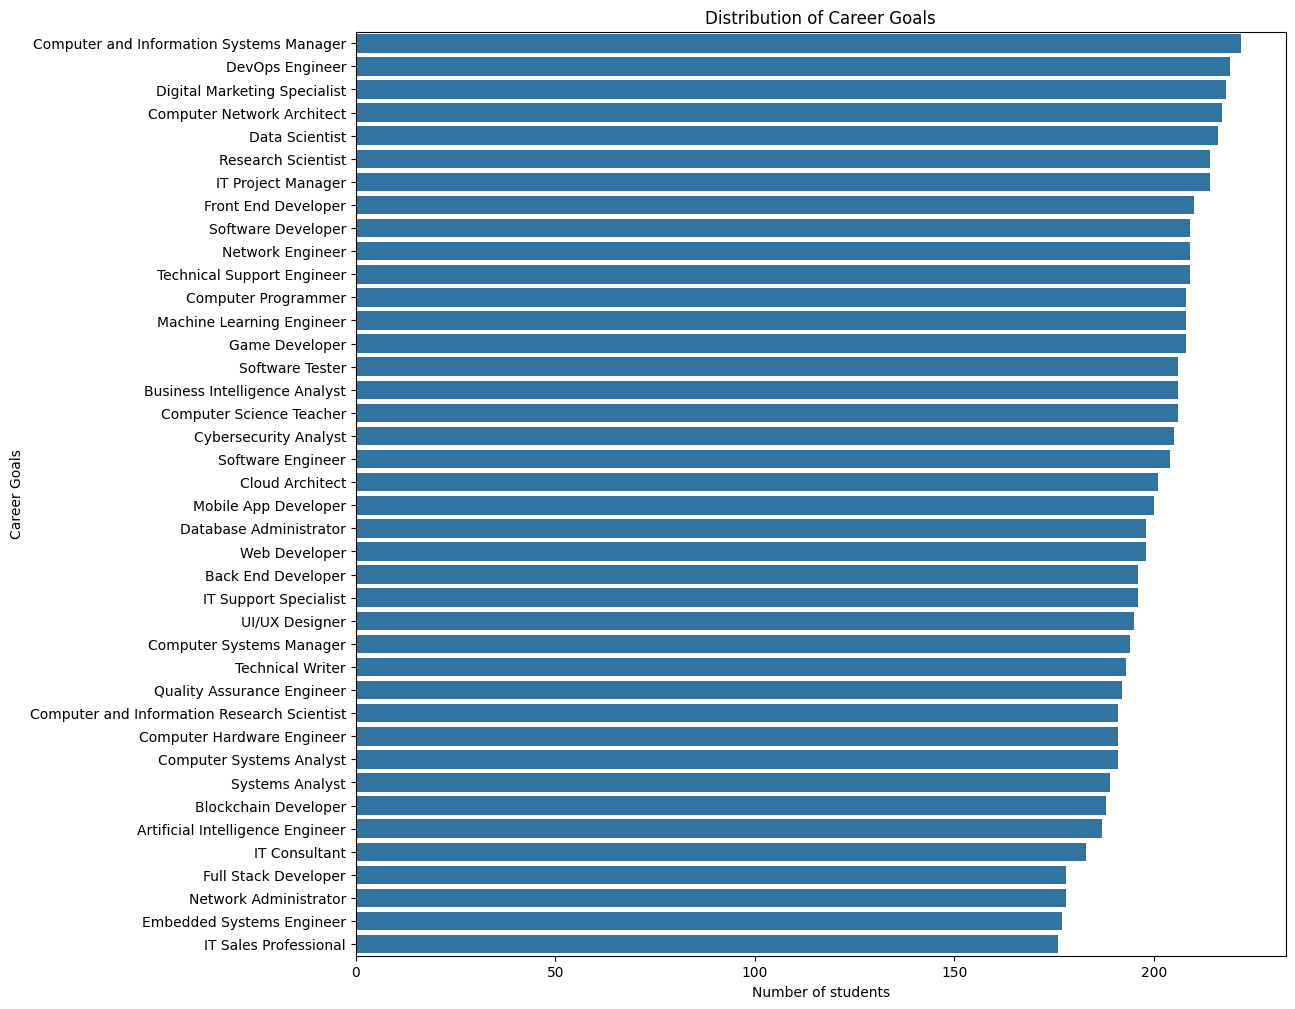

In [51]:
plt.figure(figsize = (12,12))
career_counts = data["Career_Goals"].value_counts()

sns.barplot(
    x = career_counts.values,
    y = career_counts.index
)

plt.title("Distribution of Career Goals")
plt.xlabel("Number of students")
plt.ylabel("Career Goals")
plt.show()

In [57]:
skill_columns = [
    'Python',
    'Java',
    'C++',
    'JavaScript',
    'C#',
    'PHP',
    'Ruby',
    'Swift',
    'Go',
    'Rust',
    'Others',
    'Software_Development_Experience',
    'Database_Management',
    'Networking_Skills',
    'Web_Development_Experience',
    'Communication_Skills',
    'Problem_Solving_Abilities',
    'Teamwork_Collaboration',
    'Time_Management',
    'Adaptability'
]
career_skill_means = data.groupby("Career_Goals")[skill_columns].mean()

career_skill_means.round(2)

,Python,Java,C++,JavaScript,C#,PHP,Ruby,Swift,Go,Rust,Others,Software_Development_Experience,Database_Management,Networking_Skills,Web_Development_Experience,Communication_Skills,Problem_Solving_Abilities,Teamwork_Collaboration,Time_Management,Adaptability
Career_Goals,,,,,,,,,,,,,,,,,,,,
Artificial Intelligence Engineer,4.71,4.63,4.86,4.67,4.35,4.28,4.66,4.63,4.84,4.59,4.50,4.60,4.76,4.48,4.53,4.48,4.59,4.55,4.23,4.36
Back End Developer,4.44,4.28,4.60,4.12,4.53,4.51,4.87,4.46,4.44,4.61,4.44,4.84,4.72,4.17,4.61,4.13,4.55,4.84,4.44,4.31
Blockchain Developer,4.32,4.59,4.40,4.33,4.19,4.23,4.56,4.26,4.78,4.79,4.12,4.49,4.54,4.71,3.86,4.51,4.49,4.46,4.21,4.41
Business Intelligence Analyst,4.34,4.20,4.20,4.35,3.98,4.10,4.52,4.51,4.85,4.29,3.99,4.68,4.24,4.94,4.47,4.62,4.45,4.45,4.30,4.59
Cloud Architect,4.26,4.58,4.30,5.00,4.65,4.37,4.14,4.54,4.37,4.71,4.52,4.55,4.64,4.32,4.58,4.44,4.53,4.25,4.57,4.56
Computer Hardware Engineer,4.74,4.85,4.31,4.32,4.33,4.73,4.55,4.27,4.58,4.23,4.56,4.68,4.26,4.65,4.32,4.70,4.79,4.30,4.41,4.57
Computer Network Architect,4.21,4.57,4.85,4.42,4.55,4.36,4.80,4.59,4.46,4.53,4.32,4.72,4.35,4.57,4.43,4.45,4.34,4.43,4.70,4.83
Computer Programmer,4.50,5.05,4.76,4.28,4.88,4.61,4.73,4.38,4.95,4.29,4.80,4.38,4.54,4.55,4.83,4.59,4.70,4.23,4.82,4.41
Computer Science Teacher,4.69,4.60,5.00,4.37,4.66,4.36,4.37,4.44,4.68,4.50,4.17,4.51,4.37,4.54,4.26,4.67,4.57,4.21,4.35,4.50


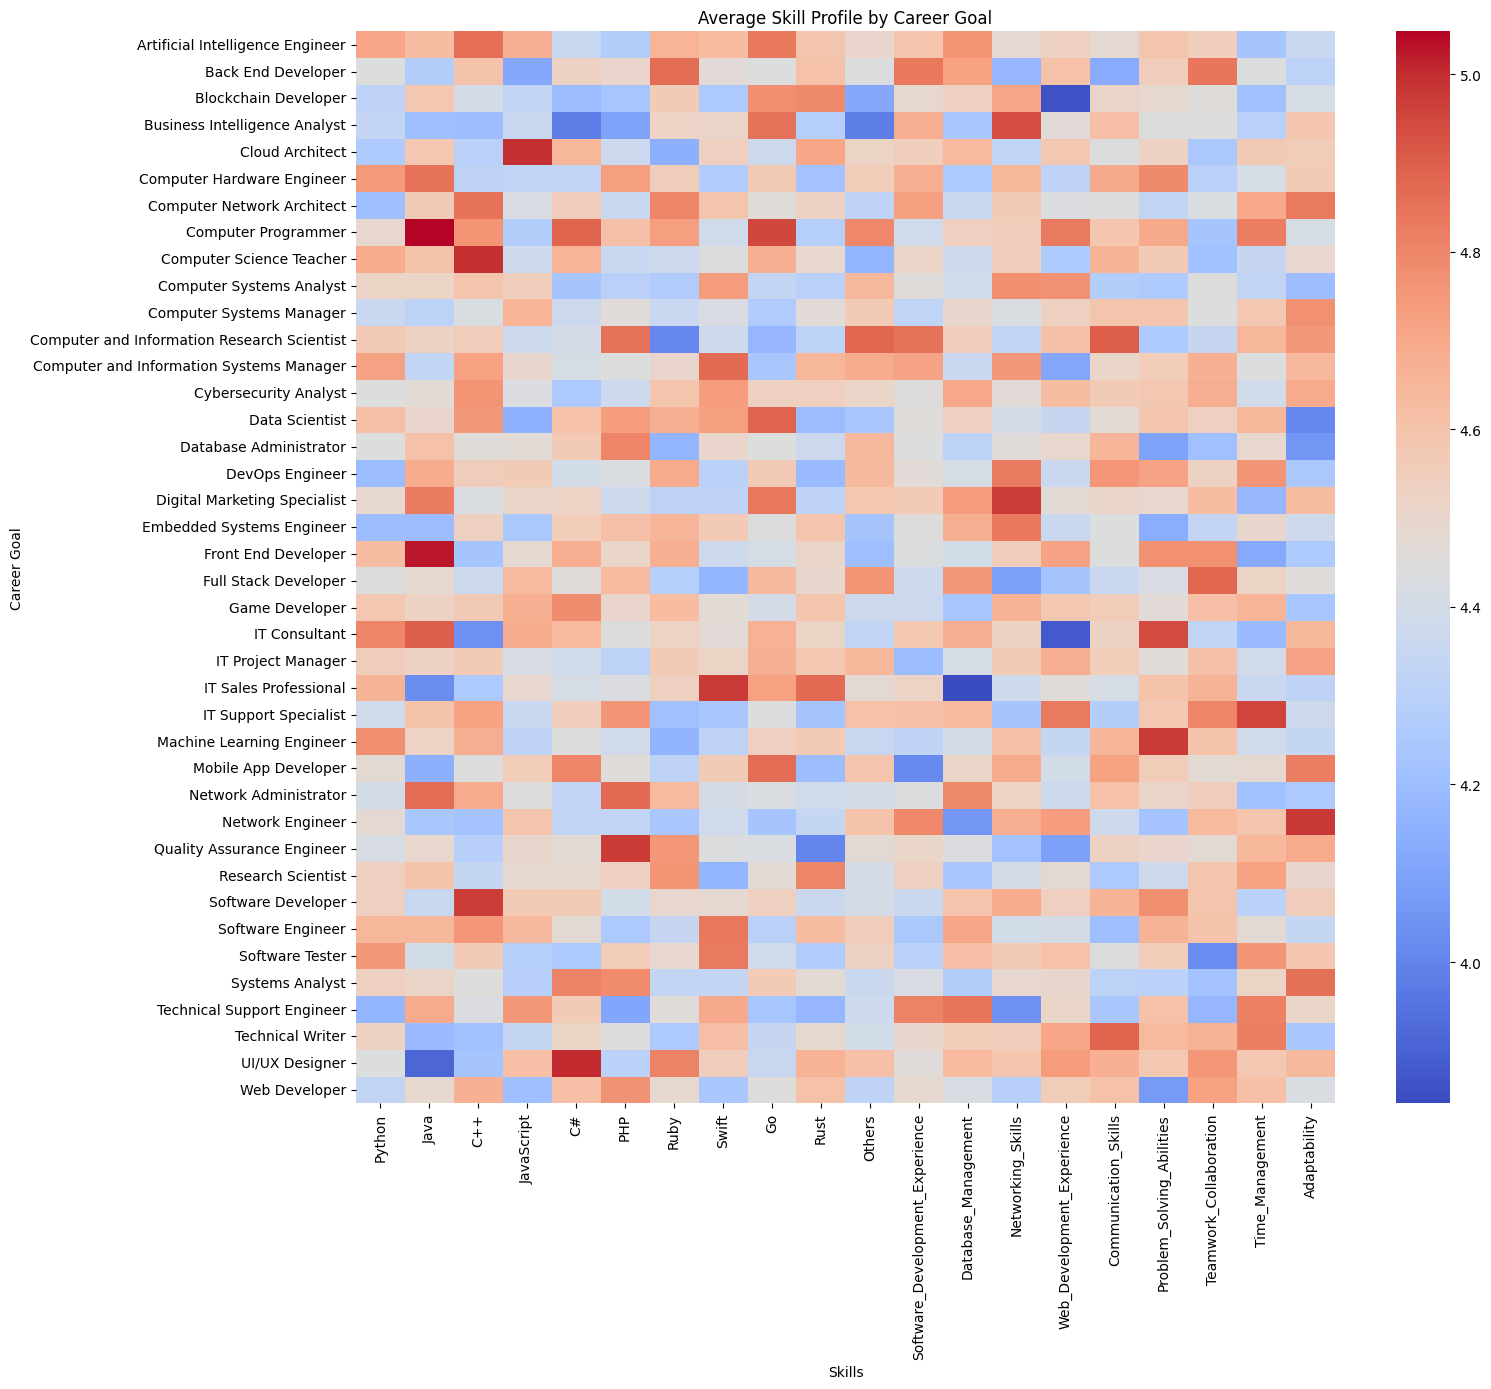

In [59]:
plt.figure(figsize=(16, 14))

sns.heatmap(
    career_skill_means,
    annot=False,
    cmap="coolwarm"
)

plt.title("Average Skill Profile by Career Goal")
plt.xlabel("Skills")
plt.ylabel("Career Goal")

plt.tight_layout()
plt.show()

In [67]:
for col in categorical_columns:
    print("\n" + "=" * 60)
    print(col)
    print(data[col].value_counts())


Coursework_Completion_Status
Coursework_Completion_Status
In Progress    4011
Completed      3989
Name: count, dtype: int64

Academic_Achievements
Academic_Achievements
Medium    4869
Low       1585
High      1546
Name: count, dtype: int64

Personal_Interests
Personal_Interests
Gaming          1391
CodingOthers    1376
Sports          1357
Reading         1322
Traveling       1316
Music           1238
Name: count, dtype: int64

Internship_Experience
Internship_Experience
Yes    4056
No     3944
Name: count, dtype: int64

Certifications_Training
Certifications_Training
No     4027
Yes    3973
Name: count, dtype: int64

Leadership_Experience
Leadership_Experience
No     4056
Yes    3944
Name: count, dtype: int64


In [73]:
X = data[categorical_columns + numerical_columns]
y = data["Career_Goals"]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X, y,
        test_size = 0.2,
        random_state = 42,
        stratify = y
    )
)

In [80]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
preprocessor.fit_transform(X_train)
preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Transformed X_train shape:", X_train_transformed.shape)

print("Original X_test shape:", X_test.shape)
print("Transformed X_test shape:", X_test_transformed.shape)

Original X_train shape: (6400, 27)
Transformed X_train shape: (6400, 38)
Original X_test shape: (1600, 27)
Transformed X_test shape: (1600, 38)


In [93]:
logistic_model = LogisticRegression(max_iter=2000, random_state=42)

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", logistic_model)
])

logistic_pipeline.fit(X_train, y_train)
y_pred = logistic_pipeline.predict(X_test)
print("Best Career Goal Prediction: \n", y_pred[:3])

Best Career Goal Prediction: 
 ['IT Support Specialist' 'Computer and Information Systems Manager'
 'Game Developer']


In [107]:
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy: ",accuracy)

classification_rep = classification_report(y_pred, y_test)
print("Classification Report:")
print(classification_rep)

Accuracy:  0.018125
Classification Report:
                                             precision    recall  f1-score   support

           Artificial Intelligence Engineer       0.00      0.00      0.00        25
                         Back End Developer       0.00      0.00      0.00        36
                       Blockchain Developer       0.03      0.02      0.02        50
              Business Intelligence Analyst       0.07      0.07      0.07        45
                            Cloud Architect       0.03      0.04      0.03        23
                 Computer Hardware Engineer       0.00      0.00      0.00        44
                 Computer Network Architect       0.00      0.00      0.00        67
                        Computer Programmer       0.07      0.03      0.04        92
                   Computer Science Teacher       0.00      0.00      0.00        26
                   Computer Systems Analyst       0.00      0.00      0.00        11
                   Co

In [109]:
y_prob = logistic_pipeline.predict_proba(X_test)
top_k_accuracy = top_k_accuracy_score(
    y_test,
    y_prob,
    k=3,
    labels = logistic_pipeline.classes_
)

print(f"Top-3 Accuracy: {top_k_accuracy: .4f}")

Top-3 Accuracy:  0.0644


In [114]:
knn_model = KNeighborsClassifier(n_neighbors = 5)

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", knn_model)
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
print("KNN Best Career Goal Prediction: \n", y_pred_knn[:3])

KNN Best Career Goal Prediction: 
 ['Computer Programmer' 'Software Developer'
 'Business Intelligence Analyst']


In [116]:
knn_accuracy = accuracy_score(y_pred, y_test)
print("KNN accuracy: ", knn_accuracy)

knn_classification_rep = classification_report(y_pred_knn, y_test)
print("KNN Classification Report: ")
print(knn_classification_rep)

knn_top_3_acc = top_k_accuracy_score(
    y_test,
    knn_pipeline.predict_proba(X_test),
    k = 3,
    labels = knn_pipeline.classes_
)
print("KNN Top-3 Accuracy: ", knn_top_3_acc)

KNN accuracy:  0.018125
KNN Classification Report: 
                                             precision    recall  f1-score   support

           Artificial Intelligence Engineer       0.16      0.03      0.06       172
                         Back End Developer       0.10      0.03      0.05       128
                       Blockchain Developer       0.14      0.03      0.05       158
              Business Intelligence Analyst       0.17      0.05      0.07       152
                            Cloud Architect       0.07      0.04      0.05        85
                 Computer Hardware Engineer       0.03      0.01      0.02        91
                 Computer Network Architect       0.07      0.04      0.05        80
                        Computer Programmer       0.02      0.01      0.02        73
                   Computer Science Teacher       0.02      0.01      0.02        79
                   Computer Systems Analyst       0.00      0.00      0.00        47
            

In [122]:
dt_classifier = DecisionTreeClassifier(random_state = 42)

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", dt_classifier)
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
print("Decision Tree Best Career Goal Prediction: \n", y_pred_dt[:3])


Decision Tree Best Career Goal Prediction: 
 ['Cloud Architect' 'Database Administrator' 'Cloud Architect']


In [ ]:
dt_accuracy = accuracy_score(y_pred_dt, y_test)
print("Decision Tree Accuracy: ", dt_accuracy)

dt_classification_rep = classification_report(y_pred_dt, y_test)
print("Decision Tree Classification Report: \n", dt_classification_rep)

dt_top_3_acc = top_k_accuracy_score(
    y_test,
    dt_pipeline.predict_proba(X_test),
    k = 3,
    labels = dt_pipeline.classes_
)

print("DecisionTreeClassifier Top-3 Accuracy: ", dt_top_3_acc)



Decision Tree Accuracy:  0.025
Decision Tree Classification Report: 
                                              precision    recall  f1-score   support

           Artificial Intelligence Engineer       0.00      0.00      0.00        36
                         Back End Developer       0.00      0.00      0.00        31
                       Blockchain Developer       0.00      0.00      0.00        24
              Business Intelligence Analyst       0.02      0.03      0.03        39
                            Cloud Architect       0.00      0.00      0.00        45
                 Computer Hardware Engineer       0.03      0.03      0.03        35
                 Computer Network Architect       0.02      0.03      0.02        38
                        Computer Programmer       0.00      0.00      0.00        43
                   Computer Science Teacher       0.05      0.04      0.04        48
                   Computer Systems Analyst       0.05      0.08      0.06     

In [128]:
rf_classifier = RandomForestClassifier(random_state = 42, n_estimators = 200, n_jobs = -1)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf_classifier)
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
print("Random Forest Best Career Goal Prediction: \n", y_pred_rf[:3])


Random Forest Best Career Goal Prediction: 
 ['Computer and Information Research Scientist' 'Cybersecurity Analyst'
 'Research Scientist']


In [ ]:
rf_accuracy = accuracy_score(y_pred_rf, y_test)
print("Random Forest Accuracy: ", rf_accuracy)

rf_classification_rep = classification_report(y_pred_rf, y_test)
print("Random Forest Classification Report: \n", rf_classification_rep)

rf_top3_acc = top_k_accuracy_score(
    y_test,
    rf_pipeline.predict_proba(X_test),
    k = 3,
    labels = rf_pipeline.classes_
)

print("Random Forest Top-3 Accuracy: ", rf_top3_acc)


Random Forest Accuracy:  0.030625
Random Forest Classification Report: 
                                              precision    recall  f1-score   support

           Artificial Intelligence Engineer       0.08      0.06      0.07        47
                         Back End Developer       0.03      0.02      0.02        52
                       Blockchain Developer       0.00      0.00      0.00        38
              Business Intelligence Analyst       0.02      0.02      0.02        66
                            Cloud Architect       0.03      0.03      0.03        40
                 Computer Hardware Engineer       0.03      0.02      0.02        43
                 Computer Network Architect       0.05      0.03      0.04        68
                        Computer Programmer       0.02      0.01      0.02        69
                   Computer Science Teacher       0.05      0.04      0.05        47
                   Computer Systems Analyst       0.05      0.08      0.06  

In [139]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xg_classifier = XGBClassifier(n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
    )

xg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xg_classifier)
])

xg_pipeline.fit(X_train, y_train_encoded)
y_pred_xg_encoded = xg_pipeline.predict(X_test)

y_pred_xg = label_encoder.inverse_transform(y_pred_xg_encoded)

print("XGBoost Best Career Goal Prediction: \n", y_pred_xg[:3])


XGBoost Best Career Goal Prediction: 
 ['Computer Systems Manager' 'Computer Science Teacher' 'Network Engineer']


In [ ]:
xg_accuracy = accuracy_score(y_pred_xg, y_test)
print("XGBoost Accuracy: ", xg_accuracy)

xg_classification_rep = classification_report(y_pred_xg, y_test)
print("XGBoost Classification Report: \n", xg_classification_rep)

xg_top3_acc = top_k_accuracy_score(
    y_test_encoded,
    xg_pipeline.predict_proba(X_test),
    k=3,
    labels=xg_pipeline.classes_
)
print("XGB classifier Top-3 accuracy: ", xg_top3_acc)


XGBoost Accuracy:  0.021875
XGBoost Classification Report: 
                                              precision    recall  f1-score   support

           Artificial Intelligence Engineer       0.03      0.03      0.03        30
                         Back End Developer       0.03      0.03      0.03        31
                       Blockchain Developer       0.03      0.02      0.03        42
              Business Intelligence Analyst       0.00      0.00      0.00        46
                            Cloud Architect       0.03      0.04      0.03        25
                 Computer Hardware Engineer       0.08      0.10      0.09        30
                 Computer Network Architect       0.02      0.02      0.02        50
                        Computer Programmer       0.02      0.03      0.02        40
                   Computer Science Teacher       0.02      0.02      0.02        60
                   Computer Systems Analyst       0.00      0.00      0.00        26
   

In [149]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy,
        "Top-3 Accuracy": top_k_accuracy
    },
    {
        "Model": "KNN",
        "Accuracy": knn_accuracy,
        "Top-3 Accuracy": knn_top_3_acc
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Top-3 Accuracy": dt_top_3_acc
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Top-3 Accuracy": rf_top3_acc
    },
    {
        "Model": "XGBoost",
        "Accuracy": xg_accuracy,
        "Top-3 Accuracy": xg_top3_acc
    }
]

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Top-3 Accuracy",
    ascending=False
)

,Model,Accuracy,Top-3 Accuracy
1,KNN,0.018125,0.086250
4,XGBoost,0.021875,0.086250
3,Random Forest,0.030625,0.077500
2,Decision Tree,0.025000,0.072500
0,Logistic Regression,0.018125,0.064375


In [151]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", dummy_model)
])

dummy_pipeline.fit(X_train, y_train)

dummy_pred = dummy_pipeline.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)

print(f"Dummy Accuracy: {dummy_accuracy:.4f}")

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    data[numerical_columns],
    data["Career_Goals"],
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": numerical_columns,
    "Mutual_Information": mi_scores
}).sort_values(
    by="Mutual_Information",
    ascending=False
)

mi_df

Dummy Accuracy: 0.0275


,Feature,Mutual_Information
10,Others,0.021777
14,Web_Development_Experience,0.016555
9,Rust,0.015705
8,Go,0.012557
11,Software_Development_Experience,0.008902
0,Python,0.007751
4,C#,0.003789
19,Adaptability,0.002796
2,C++,0.002710
15,Communication_Skills,0.002705


In [152]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

X_cat = data[categorical_columns].copy()

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_cat_encoded = encoder.fit_transform(X_cat)

mi_cat = mutual_info_classif(
    X_cat_encoded,
    data["Career_Goals"],
    discrete_features=True,
    random_state=42
)

mi_cat_df = pd.DataFrame({
    "Feature": categorical_columns,
    "Mutual_Information": mi_cat
}).sort_values(
    "Mutual_Information",
    ascending=False
)

mi_cat_df

,Feature,Mutual_Information
2,Personal_Interests,0.012289
1,Academic_Achievements,0.004337
0,Coursework_Completion_Status,0.003063
4,Certifications_Training,0.003004
3,Internship_Experience,0.002705
5,Leadership_Experience,0.001941
